# Domain wall width

Relax a 1D domain wall in a uniaxial film and compare its width with the analytic value $\Delta = \sqrt{A/K_\mathrm{eff}}$. No demag.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skyrmion_simulator.simulator.params_helper import make_params
from skyrmion_simulator.simulator.pulses import ConstantPulse
mu0 = 4.0e-7 * np.pi
from skyrmion_simulator.simulator.relaxation import relax

Material and lattice. `make_params` takes the bare anisotropy `K`, so add the thin-film demag term to reach the target `K_eff`.

In [2]:
A_ex, K_eff, Ms = 15.0e-12, 1.0e5, 1.0e6
a, nx, ny = 1.0e-9, 200, 4
K = K_eff + 0.5 * mu0 * Ms**2
p = make_params(nx=nx, ny=ny, a=a, A_ex=A_ex, D=0.0, K_top=K, K_bot=K,
                Ms=Ms, alpha=1.0, H_RKKY=0.0, H_ext=np.zeros(3),
                dt=1.0e-13, pulse=ConstantPulse(0.0))

Initial state: up domain in the middle, down outside, with walls deliberately too narrow.

In [3]:
x = (np.arange(nx) + 0.5) * a
theta = (2 * np.arctan(np.exp((x - 50e-9) / 5e-9))
         - 2 * np.arctan(np.exp((x - 150e-9) / 5e-9)))
m0 = np.zeros((ny, nx, 3))
m0[..., 0] = np.sin(theta)
m0[..., 2] = np.cos(theta)

Relax. The second argument is the partner layer; `None` means a single layer.

In [4]:
m, _, converged, n_steps, _, tau = relax(
    m0, None, p, None, max_steps=100000, tol_torque=1.0e-5,
    check_every=500)
print(f'converged={converged} after {n_steps} steps, '
      f'max torque {tau:.2e} T')

converged=True after 4500 steps, max torque 8.15e-06 T


Wall width from the steepest slope of the polar angle.

In [5]:
theta_fin = np.arccos(np.clip(m[0, :, 2], -1.0, 1.0))
delta_sim = 1.0 / np.max(np.abs(np.gradient(theta_fin, a)))
delta_an = np.sqrt(A_ex / K_eff)
print(f'Delta simulated = {delta_sim*1e9:.2f} nm, '
      f'analytic = {delta_an*1e9:.2f} nm')

Delta simulated = 12.28 nm, analytic = 12.25 nm


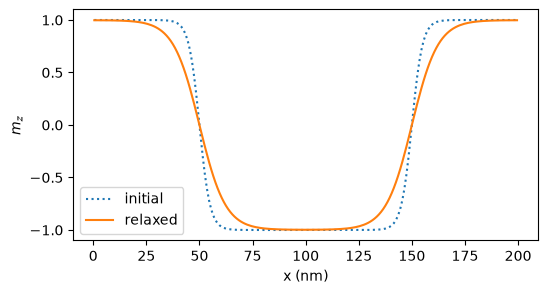

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x * 1e9, m0[0, :, 2], ':', label='initial')
ax.plot(x * 1e9, m[0, :, 2], label='relaxed')
ax.set_xlabel('x (nm)')
ax.set_ylabel('$m_z$')
ax.legend()
plt.show()